# Engineering eigenvalues -- a structure's resonances are an eigenproblem
### natural frequencies = eigenvalues, mode shapes = eigenvectors (in torch)

Ask "how does this structure vibrate?" and you are asking for **eigenvalues**. A
chain of $N$ masses on springs obeys $m\ddot{\mathbf x}=-K\mathbf x$; the natural
frequencies are $\omega_j=\sqrt{\lambda_j}$ where $\lambda_j$ are the eigenvalues of
the dynamical matrix $D=K/m$, and the **mode shapes** are its eigenvectors. We solve
it with `torch.linalg.eigh` and recover the closed form to machine precision. It is
the *same* eigenvalue structure as the Bessel drumhead (`dgs.bessel_linalg`) and the
quantum particle in a box -- eigenvalues are how engineers find resonances, buckling
loads, and PCA axes alike. Torch. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import torch
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import eigen_modes as em
print("torch", torch.__version__)

torch 2.11.0+cu128


## 1. Build the dynamical matrix and diagonalize it

For $N$ equal masses and springs, $D=\tfrac{k}{m}\,\mathrm{tridiag}(-1,2,-1)$. Its
eigenvalues are $\omega_j^2$; `torch.linalg.eigh` returns them (ascending) with the
mode shapes. They match the closed form $\omega_j=2\sqrt{k/m}\sin\!\frac{j\pi}{2(N+1)}$.

In [2]:
N, k, m = 24, 4.0, 0.5
D = em.chain_dynamical_matrix(N, k, m)
omega, modes = em.normal_modes(D)
ref = em.chain_frequencies_analytic(N, k, m)
print("first five natural frequencies (torch vs analytic):")
for j in range(5):
    print(f"  mode {j+1}: omega = {omega[j].item():.5f}   analytic {ref[j]:.5f}")
print(f"\nmax |torch - analytic| = {np.max(np.abs(omega.numpy()-ref)):.2e}  (machine precision)")

first five natural frequencies (torch vs analytic):
  mode 1: omega = 0.35520   analytic 0.35520
  mode 2: omega = 0.70899   analytic 0.70899
  mode 3: omega = 1.05999   analytic 1.05999
  mode 4: omega = 1.40680   analytic 1.40680
  mode 5: omega = 1.74806   analytic 1.74806

max |torch - analytic| = 3.72e-15  (machine precision)


## 2. The frequency spectrum (the chain's dispersion)

Plotting $\omega_j$ vs mode number $j$ gives the chain's **dispersion curve**: nearly
linear for the low modes (long-wavelength sound waves) and **saturating** toward
$2\sqrt{k/m}$ at the top -- the highest frequency a discrete lattice can carry.

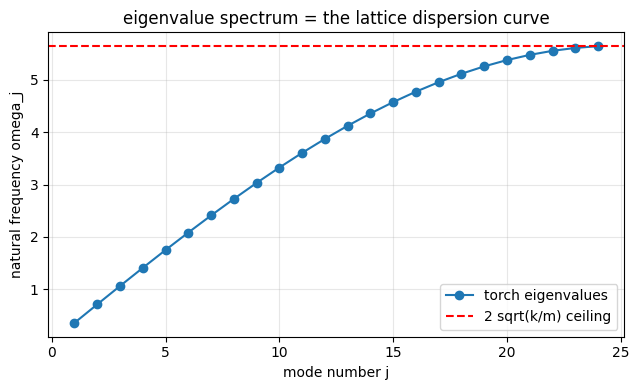

In [3]:
j = np.arange(1, N+1)
plt.figure(figsize=(6.5,4))
plt.plot(j, omega.numpy(), "o-", label="torch eigenvalues")
plt.axhline(2*np.sqrt(k/m), color="r", ls="--", label="2 sqrt(k/m) ceiling")
plt.xlabel("mode number j"); plt.ylabel("natural frequency omega_j"); plt.legend()
plt.title("eigenvalue spectrum = the lattice dispersion curve"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The mode shapes (eigenvectors are standing waves)

Each eigenvector is a standing sine: mode $j$ has $j-1$ interior nodes. The
fundamental ($j=1$) has all masses swinging together; higher modes subdivide. These
are the literal shapes the structure rings in.

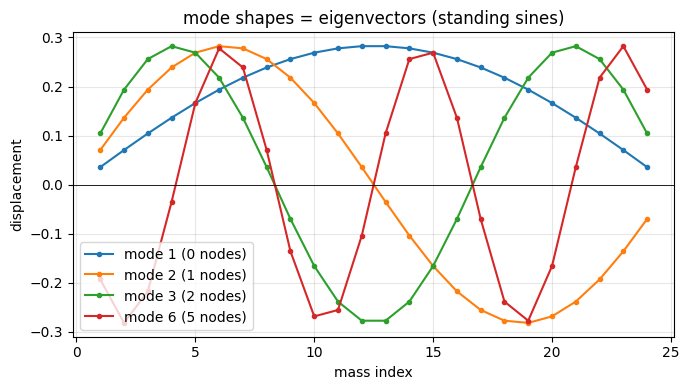

In [4]:
xpos = np.arange(1, N+1)
plt.figure(figsize=(7,4))
for j in (1, 2, 3, 6):
    v = modes[:, j-1].numpy()
    if v[np.argmax(np.abs(v))] < 0: v = -v        # sign-fix for display
    plt.plot(xpos, v, "o-", ms=3, label=f"mode {j} ({j-1} nodes)")
plt.axhline(0, color="k", lw=0.6); plt.xlabel("mass index"); plt.ylabel("displacement")
plt.title("mode shapes = eigenvectors (standing sines)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. The same eigenproblem, everywhere

| system | operator | eigenvalues | eigenvectors |
|---|---|---|---|
| mass-spring chain (here) | dynamical matrix $K/m$ | natural frequencies $\omega_j^2$ | mode shapes |
| circular drum (`bessel_linalg`) | radial Laplacian | Bessel zeros $\alpha_m^2$ | $J_n(\alpha_m r/R)$ |
| quantum box / oscillator | Hamiltonian | energy levels $E_n$ | wavefunctions $\psi_n$ |
| data (PCA) | covariance matrix | variances | principal axes |

One idea -- diagonalize the operator -- gives resonances, spectra, and structure.
`torch.linalg.eigh` is the same tool for all of them.

## Takeaway

1. **A structure's resonances are eigenvalues** of its dynamical matrix; `eigh`
   returns the natural frequencies and the mode shapes exactly.
2. The spectrum is the **dispersion curve** (linear, then saturating); the
   eigenvectors are **standing waves** with $j-1$ nodes.
3. It is the **same eigenproblem** as the Bessel drum, the quantum box, and PCA --
   change the matrix, keep the method.

The "clock" of each mode is its period $T_j=2\pi/\omega_j$. Diagonalize once and you
know every way the system can ring. Civilian education / engineering.